# Analysis: Predicting Intraprostatic Recurrence on MRI After Radiotherapy

Primary analysis notebook — descriptive statistics, stratification, and visualizations.

All logic lives in `pca_mri.analysis` and `pca_mri.visualization`.  
Load the cleaned dataset produced by `step_1-data_cleanup.ipynb` before running.

# Outline
1. Flow diagram of patient selection and cohort derivation
2. Descriptive statistics tables
3. Missing data report
4. Distribution visualization
5. Stratification: biopsy results and MRI detection
6. Statistical Analysis — Full Pipeline & Dashboard

In [10]:
# decide whether or not to keep converters (positive -> negative MRI)
remove_converters = True

In [11]:
import sys
sys.path.insert(0, '.')  # make pca_mri importable from repo root

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('dark_background')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

from pca_mri import io
from pca_mri.analysis import descriptive, stratification
from pca_mri.visualization import timelines, kinetics
from pca_mri.visualization.sankey import plot_exclusion_sankey
from pca_mri.visualization import export_html
import glob

In [12]:
# Automatically pick the most recent cleaned file
csv_files = sorted(glob.glob('df-clean-v1_*.csv'))
clean_path = csv_files[-1]
print(f'Loading: {clean_path}')

df = io.load_clean(clean_path)
if remove_converters: df = df[~df['is_converter']].copy()

print(f'Shape: {df.shape}')

Loading: df-clean-v1_20260318_071524.csv
Shape: (65, 63)


## 1. Flow diagram of patient selection and cohort derivation

In [13]:
fig_sankey = plot_exclusion_sankey(remove_converters=remove_converters)
# fig_sankey.show()
export_html.save_figure(fig_sankey, "", "html_data/fig1_sankey.html")

Saved: html_data/fig1_sankey.html


## 2. Descriptive statistics tables
Continuous: Median [Q1–Q3], Kruskal-Wallis p-value.  
Categorical: N (%), chi-squared p-value.
* a) By treatment type
* b) By MRI recurrence detection (positive, negative)
* c) By biopsy recurrence (positive, negative)
* d) By CAPRA risk group (low, intermediate, high)

In [14]:
t1 = df.describe()
t1_a = descriptive.table1(df, stratify_by='tx-type', title = "Descriptive Statistics Stratified by Treatment")
t1_b = descriptive.table1(df, stratify_by='rec_mri-result', title = "Descriptive Statistics Stratified by MRI Recurrence Result")
t1_c = descriptive.table1(df, stratify_by='biopsy-result', title = "Descriptive Statistics Stratified by Biopsy Result")
t1_d = descriptive.table1(df, stratify_by='capra-risk_group', title = "Descriptive Statistics Stratified by CAPRA Risk Group")

In [15]:
t1 = {
    "tx-type": descriptive.style_table(t1_a),
    "rec_mri-result": descriptive.style_table(t1_b),
    "biopsy-result": descriptive.style_table(t1_c),
    "capra-risk_group": descriptive.style_table(t1_d),
}
export_html.save_descriptive_stats_tables(t1, "html_data/t1-descriptive_stats.html")

Saved: html_data/t1-descriptive_stats.html


## 3. Missing data report

In [16]:
t2 = descriptive.missing_data_summary(df)
t2_styled = descriptive.style_missing_table(t2)
# t2_styled
export_html.save_table(t2_styled, "", "html_data/t2-missing_data.html")

Saved: html_data/t2-missing_data.html


## 4. Distribution visualization

In [17]:
from pca_mri.visualization.descriptive_plots import plot_kde, plot_category_bar, plot_histogram
from pca_mri.visualization import export_html
import ipywidgets as widgets
from IPython.display import display
from pca_mri.analysis.descriptive import _CATEGORICAL, _CONTINUOUS

# Build dropdown options from _CATEGORICAL / _CONTINUOUS (label shown, column value used)
cat_options  = [(label, col) for col, label in _CATEGORICAL if col in df.columns]
cont_options = [(label, col) for col, label in _CONTINUOUS  if col in df.columns]

cat_dd = widgets.Dropdown(
    options=cat_options,
    value='tx-type',
    description='Categorical:',
    style={'description_width': 'initial'},
)
cont_dd = widgets.Dropdown(
    options=cont_options,
    value='tx-age',
    description='Continuous:',
    style={'description_width': 'initial'},
)

out = widgets.Output()


def update(cat, cont):
    out.clear_output(wait=True)
    with out:
        plot_category_bar(df, cat, cont).show()
        plot_histogram(df, cat, cont).show()
        plot_kde(df, cat, cont).show()


cat_dd.observe( lambda _: update(cat_dd.value, cont_dd.value), names='value')
cont_dd.observe(lambda _: update(cat_dd.value, cont_dd.value), names='value')

display(widgets.VBox([widgets.HBox([cat_dd, cont_dd]), out]))
update(cat_dd.value, cont_dd.value)

In [18]:
export_html.save_interactive_explorer(df, "html_data/fig2-explorer.html")

Saved: html_data/fig2-explorer.html


## 5. Stratification: biopsy results and MRI detection

The cohort is split by **biopsy result** (primary definition of confirmed recurrence) and by **MRI detection status**.

- **Biopsy-positive**: recurrence histologically confirmed (N ≈ 46)
- **Biopsy-negative**: biopsy performed but no confirmed recurrence (N ≈ 20)
- **No biopsy**: 41 patients have no biopsy result — excluded from biopsy-based analyses

### A. Cross-tabulation of biopsy result vs. MRI detection

### B. BF-to-MRI lag (biopsy-positive patients only)

### C. Serial MRI follow-up visits per 

### D. PSA kinetics

In [19]:
# ── A. Cross-tabulation: biopsy result vs MRI detection ──
# Patients with no biopsy are excluded; they do not contribute to either biopsy group.
_POSITIVE_BIOPSY = {'positif', 'positive', 'positiv'}
_NEGATIVE_BIOPSY = {'négative', 'négatif', 'negative', 'negativ'}
_MRI_POSITIVE   = {'positive', 'positif', 'positiv'}
_MRI_NEGATIVE   = {'négative', 'negative', 'négatif', 'negativ'}
_MRI_EQUIVOCAL  = {'equivoque'}

biopsy_pos, biopsy_neg = stratification.split_by_recurrence(df, method='biopsy')
n_no_biopsy = df['biopsy-result'].isna().sum()

_norm = df['biopsy-result'].astype(str).str.strip().str.lower()
has_biopsy = _norm.isin(_POSITIVE_BIOPSY | _NEGATIVE_BIOPSY)
df_biopsied = df[has_biopsy].copy()
df_biopsied['biopsy_status'] = _norm[has_biopsy].apply(
    lambda x: 'Biopsy+' if x in _POSITIVE_BIOPSY else 'Biopsy–'
)
df_biopsied['mri_positive'] = df_biopsied['rec_mri-index'].notna().map(
    {True: 'MRI+', False: 'MRI−'}
)

crosstab = pd.crosstab(
    df_biopsied['biopsy_status'],
    df_biopsied['mri_positive'],
    rownames=['Biopsy result'],
    colnames=['MRI detection'],
    margins=True,
)
print('Cross-tabulation: Biopsy results vs MRI-detected recurrence')
print(crosstab)

Cross-tabulation: Biopsy results vs MRI-detected recurrence
MRI detection  MRI+  MRI−  All
Biopsy result                 
Biopsy+          36    12   48
Biopsy–          13     4   17
All              49    16   65


In [20]:
# fig = timelines.plot_time_to_bf(df)
# plt.show()
# # Time to MRI recurrence — whole cohort (includes biopsy-negative and unbiopsy'd patients)
# fig = timelines.plot_time_to_rec_mri(df)
# plt.title('Time to MRI recurrence — whole cohort')
# plt.show()

# # CORRECTION: Also plot restricted to biopsy-positive patients, where recurrence is confirmed.
# fig = timelines.plot_time_to_rec_mri(biopsy_pos)
# plt.title('Time to MRI recurrence — biopsy-positive patients only (confirmed recurrence)')
# plt.show()

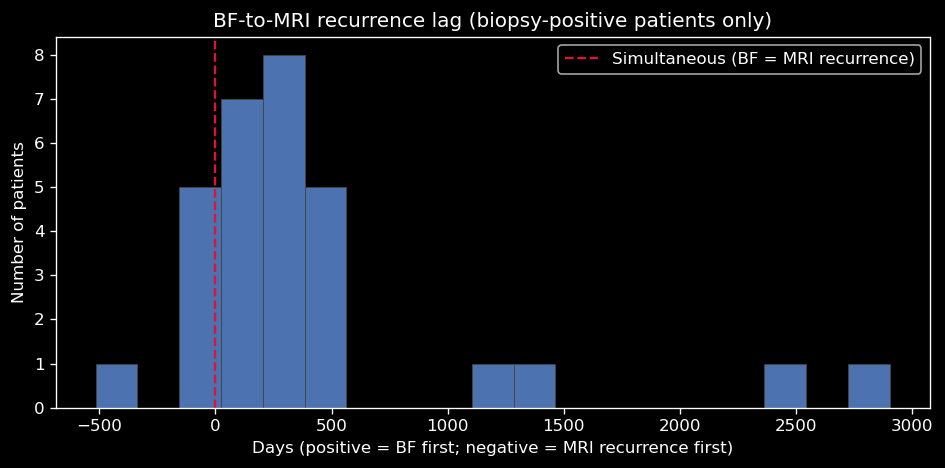

In [21]:
# ── B. BF-to-MRI lag — biopsy-positive patients only ──
# BF-to-MRI lag — biopsy-positive patients only
# (The lag between biochemical failure and MRI recurrence detection is only
#  clinically meaningful when recurrence is histologically confirmed.)
fig3 = timelines.plot_bf_to_mri_lag(biopsy_pos)
plt.title('BF-to-MRI recurrence lag (biopsy-positive patients only)')
plt.show()

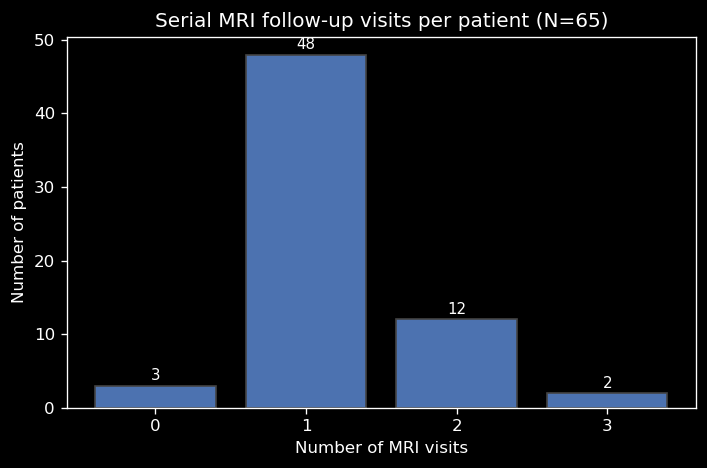

In [22]:
# ── C. Serial MRI follow-up visits per patient ──
fig4 = timelines.plot_mri_followup_count(df)
plt.show()

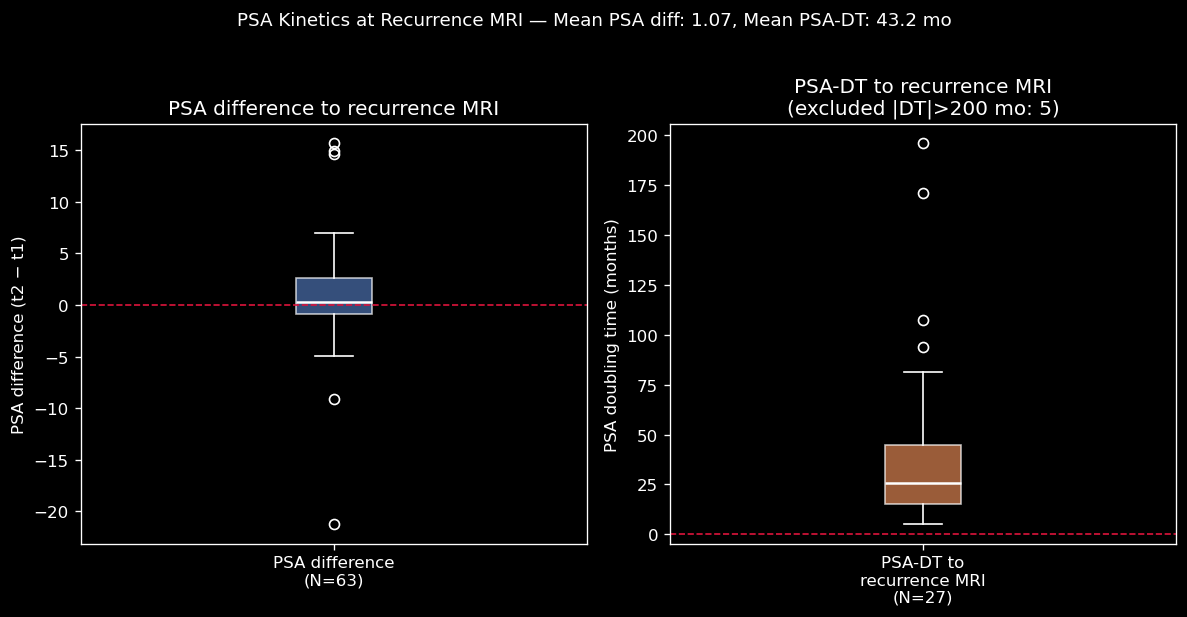

Saved: html_data/fig3-stratification.html


In [23]:
# ── Export Section 5 as a single composite HTML file ──
from pca_mri.visualization.export_html import save_composite

# Style the crosstab for dark-theme export
crosstab_styled = (
    crosstab.style
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#0f0f23"), ("color", "#e0e0e0"),
            ("border", "1px solid #333"), ("padding", "8px 10px"),
            ("font-weight", "600"),
        ]},
        {"selector": "td", "props": [
            ("background-color", "#1a1a2e"), ("color", "#e0e0e0"),
            ("border", "1px solid #333"), ("padding", "6px 10px"),
        ]},
        {"selector": "", "props": [
            ("border-collapse", "collapse"),
            ("font-family", '"Open Sans", verdana, arial, sans-serif'),
        ]},
    ])
    .set_caption("Cross-tabulation: Biopsy Result vs MRI Detection")
    .set_table_styles([
        {"selector": "caption", "props": [
            ("font-size", "14px"), ("font-weight", "bold"),
            ("text-align", "left"), ("padding", "8px 4px"),
            ("color", "#e0e0e0"),
        ]},
    ], overwrite=False)
)

# PSA kinetics figure (with mean values in title)
fig5 = kinetics.plot_psa_doubling_time(df)
plt.show()

save_composite(
    [
        ("A. Cross-tabulation: Biopsy Result vs MRI Detection", crosstab_styled),
        ("B. BF-to-MRI Recurrence Lag (Biopsy-Positive Patients)", fig3),
        ("C. Serial MRI Follow-up Visits per Patient", fig4),
        ("D. PSA Kinetics at Recurrence MRI", fig5),
    ],
    "html_data/fig3-stratification.html",
    title="Stratification: Biopsy Result and MRI Detection",
    subtitle=(
        "Agreement between imaging and pathology, time lag between "
        "biochemical failure and MRI-detected recurrence, serial "
        "MRI follow-up visit counts, and PSA kinetics."
    ),
)

In [24]:
# # PSA trajectories — whole cohort
# fig = kinetics.plot_psa_trajectory(df)
# plt.title('PSA trajectories — whole cohort')
# plt.show()

# # CORRECTION: Stratify PSA trajectories by biopsy result.
# # Previously the analysis assumed all patients were recurrent; we now compare
# # biopsy-positive vs biopsy-negative patients to assess whether PSA kinetics
# # differ between confirmed recurrence and non-recurrence.
# fig = kinetics.plot_psa_trajectory(biopsy_pos)
# plt.title('PSA trajectories — biopsy-positive (confirmed recurrence, N={})'.format(len(biopsy_pos)))
# plt.show()

# fig = kinetics.plot_psa_trajectory(biopsy_neg)
# plt.title('PSA trajectories — biopsy-negative (no confirmed recurrence, N={})'.format(len(biopsy_neg)))
# plt.show()

## 6. Statistical Analysis — Full Pipeline & Dashboard

Implements the statistical analysis plan (SAP):
1. **Objective 1:** Prevalence of MRI-visible recurrence with 95% CI
2. **Objective 2:** Diagnostic accuracy of MRI (vs biopsy reference standard)
3. **Objective 3a:** Univariate logistic regression (16 candidate predictors)
4. **Objective 3b:** Multivariable logistic regression with VIF check & bootstrap validation
5. **Interactive dashboard** combining all results

In [26]:
from pca_mri.analysis import diagnostic, regression
from pca_mri.visualization.dashboard import show_dashboard

### 11.1 Objective 1: Prevalence of MRI-Positive Recurrence
* Method to compute p-value: Chi-square test.
* Method to 95% confidence intervals: Clopper–Pearson method.

In [27]:
# Overall prevalence with 95% Clopper-Pearson CI
prev = diagnostic.prevalence(df)
print(f"MRI-Positive Recurrence Prevalence")
print(f"  {prev['n_positive']}/{prev['n_total']} = {prev['prevalence']:.1%}")
print(f"  95% CI: [{prev['ci_lower']:.1%} – {prev['ci_upper']:.1%}]")
print()

# Prevalence by treatment type
prev_tx = diagnostic.prevalence_by_subgroup(df, by="tx-type")
print("Prevalence by treatment type:")
for _, row in prev_tx.iterrows():
    print(f"  {row['group']}: {row['n_positive']}/{row['n_total']} = {row['prevalence']:.1%} "
          f"[{row['ci_lower']:.1%} – {row['ci_upper']:.1%}]")
if "p_value" in prev_tx.attrs:
    print(f"  p = {prev_tx.attrs['p_value']:.3f}")
print()

# Prevalence by CAPRA risk group
prev_capra = diagnostic.prevalence_by_subgroup(df, by="capra-risk_group")
print("Prevalence by CAPRA risk group:")
for _, row in prev_capra.iterrows():
    print(f"  {row['group']}: {row['n_positive']}/{row['n_total']} = {row['prevalence']:.1%} "
          f"[{row['ci_lower']:.1%} – {row['ci_upper']:.1%}]")
if "p_value" in prev_capra.attrs:
    print(f"  p = {prev_capra.attrs['p_value']:.3f}")

MRI-Positive Recurrence Prevalence
  49/65 = 75.4%
  95% CI: [63.1% – 85.2%]

Prevalence by treatment type:
  HDR: 7/7 = 100.0% [59.0% – 100.0%]
  LDR: 31/44 = 70.5% [54.8% – 83.2%]
  RT: 11/14 = 78.6% [49.2% – 95.3%]
  p = 0.230

Prevalence by CAPRA risk group:
  High: 4/5 = 80.0% [28.4% – 99.5%]
  Intermediate: 27/36 = 75.0% [57.8% – 87.9%]
  Low: 18/24 = 75.0% [53.3% – 90.2%]
  p = 0.969


/Users/nadiablostein/opt/anaconda3/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning:

overflow encountered in _beta_ppf



### 11.2 Objective 2 — Diagnostic Accuracy of MRI
* Method to 95% confidence intervals: Clopper–Pearson method.

In [28]:
# 2x2 contingency table: MRI vs biopsy
ct = diagnostic.contingency_table(df)
print("2x2 Contingency Table (MRI vs Biopsy):")
print(ct)
print()

# Diagnostic accuracy metrics with 95% CI
acc = diagnostic.diagnostic_accuracy(df)
print("Diagnostic Accuracy Metrics (biopsy = reference standard):")
for _, row in acc.iterrows():
    if np.isnan(row['ci_lower']):
        print(f"  {row['metric']}: {row['value']:.3f}")
    else:
        print(f"  {row['metric']}: {row['value']:.3f} [95% CI: {row['ci_lower']:.3f} – {row['ci_upper']:.3f}]")

2x2 Contingency Table (MRI vs Biopsy):
      Biopsy+  Biopsy-
MRI+       36       13
MRI-       12        4

Diagnostic Accuracy Metrics (biopsy = reference standard):
  Sensitivity: 0.750 [95% CI: 0.604 – 0.864]
  Specificity: 0.235 [95% CI: 0.068 – 0.499]
  PPV: 0.735 [95% CI: 0.589 – 0.851]
  NPV: 0.250 [95% CI: 0.073 – 0.524]
  Accuracy: 0.615 [95% CI: 0.486 – 0.733]
  Cohen's kappa: -0.015 [95% CI: -0.327 – 0.297]


### 11.3 Objective 3a — Univariate Logistic Regression

In [29]:
# Univariate logistic regression: each predictor vs MRI+ outcome
uni = regression.univariate_screen(df)
print(f"Univariate logistic regression results ({len(uni)} predictor terms):\n")

display_cols = ['label', 'param', 'or', 'ci_lower', 'ci_upper', 'p_value', 'p_adj', 'n']
uni_display = uni[display_cols].copy()
uni_display.columns = ['Variable', 'Parameter', 'OR', '95% CI Lower', '95% CI Upper', 'p-value', 'p-adj (FDR)', 'N']

# Format for display
uni_display['OR'] = uni_display['OR'].map(lambda x: f"{x:.3f}")
uni_display['95% CI Lower'] = uni_display['95% CI Lower'].map(lambda x: f"{x:.3f}")
uni_display['95% CI Upper'] = uni_display['95% CI Upper'].map(lambda x: f"{x:.3f}")
uni_display['p-value'] = uni_display['p-value'].map(lambda x: f"{x:.3f}" if x >= 0.001 else "<0.001")
uni_display['p-adj (FDR)'] = uni_display['p-adj (FDR)'].map(lambda x: f"{x:.3f}" if x >= 0.001 else "<0.001")

uni_display

Univariate logistic regression results (16 predictor terms):



,Variable,Parameter,OR,95% CI Lower,95% CI Upper,p-value,p-adj (FDR),N
0,Age at treatment,tx-age,1.051,0.959,1.152,0.286,<0.001,65
1,PSA at diagnosis,psa-val,1.011,0.876,1.166,0.885,<0.001,65
2,Gleason score,tx-gleason_total,0.864,0.340,2.196,0.759,<0.001,65
3,Clinical T-stage,tx-t_stage,1.322,0.554,3.158,0.529,<0.001,65
4,Positive biopsy core ratio,tx-biopsy_positive_ratio,1.153,0.066,20.197,0.923,<0.001,65
5,CAPRA score,psa-capra_total,0.838,0.559,1.255,0.391,<0.001,65
6,CAPRA risk group,capra-risk_group_Intermediate,0.750,0.074,7.613,0.808,<0.001,65
7,CAPRA risk group,capra-risk_group_Low,0.750,0.070,8.089,0.813,<0.001,65
8,Treatment type,tx-type_LDR,0.000,nan,nan,<0.001,<0.001,65
9,Treatment type,tx-type_RT,0.000,nan,nan,<0.001,<0.001,65


### 11.4 Objective 3b — Multivariable Logistic Regression

Clinically-guided model using CAPRA components + time to biochemical failure. VIF > 5 triggers automatic removal of collinear predictors.

In [30]:
# Multivariable model — automatic predictor selection
mv = regression.build_multivariable_model(df)

print(f"Multivariable Logistic Regression (N={mv['n']}, events={mv['n_events']})")
print(f"AIC: {mv['aic']:.1f} | McFadden Pseudo-R²: {mv['pseudo_r2']:.3f} | AUC: {mv['roc_auc']:.3f}")
hl_stat, hl_p = mv['hosmer_lemeshow']
print(f"Hosmer-Lemeshow: χ² = {hl_stat:.2f}, p = {hl_p:.3f}")
if mv['removed_vif']:
    print(f"Removed for VIF > 5: {mv['removed_vif']}")
print()

# Summary table
mv_display = mv['summary'].copy()
mv_display['OR [95% CI]'] = mv_display.apply(
    lambda r: f"{r['or']:.2f} [{r['ci_lower']:.2f} – {r['ci_upper']:.2f}]", axis=1
)
mv_display['p-value'] = mv_display['p_value'].map(lambda x: f"{x:.3f}" if x >= 0.001 else "<0.001")
print("Adjusted Odds Ratios:")
print(mv_display[['predictor', 'OR [95% CI]', 'p-value']].to_string(index=False))
print()

# VIF table
print("Variance Inflation Factors:")
print(mv['vif'].to_string(index=False))

Multivariable Logistic Regression (N=52, events=39)
AIC: 68.1 | McFadden Pseudo-R²: 0.076 | AUC: 0.675
Hosmer-Lemeshow: χ² = 4.59, p = 0.800

Adjusted Odds Ratios:
               predictor         OR [95% CI] p-value
                  tx-age  1.06 [0.94 – 1.19]   0.336
                 psa-val  1.02 [0.86 – 1.21]   0.800
        tx-gleason_total  0.64 [0.21 – 1.95]   0.431
              tx-t_stage 2.75 [0.69 – 10.90]   0.151
tx-biopsy_positive_ratio 1.90 [0.05 – 66.44]   0.723
      bf-time_to_bf-days  1.00 [1.00 – 1.00]   0.458

Variance Inflation Factors:
                variable      VIF
      bf-time_to_bf-days 1.300804
                  tx-age 1.297754
              tx-t_stage 1.215572
        tx-gleason_total 1.144241
tx-biopsy_positive_ratio 1.141071
                 psa-val 1.062714


### 11.5 Bootstrap Internal Validation

In [31]:
# Bootstrap validation (1000 resamples) for the multivariable model
# Uses the same clinically-guided predictors (CAPRA components + time to BF)
from pca_mri.analysis.regression import CANDIDATE_PREDICTORS

_FALLBACK = {"tx-age", "psa-val", "tx-gleason_total", "tx-t_stage",
             "tx-biopsy_positive_ratio", "bf-time_to_bf-days"}
mv_predictors = [(c, l, t) for c, l, t in CANDIDATE_PREDICTORS if c in _FALLBACK]

boot = regression.bootstrap_auc(df, predictor_cols=mv_predictors, n_boot=1000)
print(f"Bootstrap Internal Validation (n_boot={boot['n_successful_boots']})")
print(f"  Apparent AUC:    {boot['apparent_auc']:.3f}")
print(f"  Optimism:        {boot['optimism']:.3f}")
print(f"  Corrected AUC:   {boot['corrected_auc']:.3f}")
print(f"  95% CI:          [{boot['ci_lower']:.3f} – {boot['ci_upper']:.3f}]")

/Users/nadiablostein/opt/anaconda3/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2383: RuntimeWarning:

overflow encountered in exp

/Users/nadiablostein/opt/anaconda3/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2383: RuntimeWarning:

overflow encountered in exp



Bootstrap Internal Validation (n_boot=992)
  Apparent AUC:    0.675
  Optimism:        0.168
  Corrected AUC:   0.506
  95% CI:          [0.342 – 0.660]


### 11.6 Results Dashboard

Interactive Plotly dashboard combining all analysis results: prevalence, diagnostic accuracy, forest plots, ROC curve, and calibration.

In [32]:
# Render the full interactive dashboard
panels = show_dashboard(df, run_multivariable=True)

In [33]:
import plotly.graph_objects as go

save_composite(
    [(name, fig) for name, fig in panels.items() if isinstance(fig, go.Figure)],
    "html_data/fig4-dashboard.html",
    title="Statistical Analysis Dashboard",
    subtitle="Objective 1: Prevalence of MRI-Positive Recurrence, diagnostic accuracy, forest plots, ROC curve, and calibration.",
)

Saved: html_data/fig4-dashboard.html
